In [26]:
# ============================================================
# TECH CHALLENGE - FASE 2
# Previsão de Qualidade de Vinhos (Classificação Binária)
# ============================================================

# ============================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, auc)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline



In [27]:
# ============================================================
# 2. CARREGAMENTO E INSPEÇÃO INICIAL DOS DADOS
# ============================================================
df = pd.read_csv('WineQT.csv')

print("=" * 60)
print("INSPEÇÃO INICIAL DOS DADOS")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"\nColunas: {df.columns.tolist()}")
print(f"\nTipos:\n{df.dtypes}")

# Verificação de dados faltantes
missing_data = df.isnull().sum().sum()
print(f"\nDados faltantes totais: {missing_data}")

print(f"\nEstatísticas descritivas:\n{df.describe().round(2)}")


INSPEÇÃO INICIAL DOS DADOS

Shape: (1143, 13)

Colunas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Tipos:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

Dados faltantes totais: 0

Estatísticas descritivas:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count        1143.00           1143.00      1143.00         1143.00   
mean            8.31              0.53         0.27            2.53   
std             1.75              0.18         0.2

In [28]:
# ============================================================
# 3. COMPREENSÃO DO PROBLEMA E DEFINIÇÃO DA VARIÁVEL ALVO
# ============================================================
print("\n" + "=" * 60)
print("1. COMPREENSÃO DO PROBLEMA")
print("=" * 60)
print("""
Contexto: O dataset WineQT contém análises físico-químicas de vinhos
tinto portugueses (variedade Vinho Verde). Cada amostra foi avaliada
por especialistas (enólogos) que atribuíram uma nota de 0 a 10.

Problema: Classificação binária para prever se um vinho é de Alta
Qualidade (nota >= 7) ou Baixa/Média Qualidade (nota < 7).

Tipo: Aprendizado Supervisionado de Classificação.
""")

# Remover coluna 'Id' (não tem poder preditivo)
df.drop('Id', axis=1, inplace=True)
print("Coluna 'Id' removida.")

# Transformação binária da variável alvo
df['quality_binary'] = (df['quality'] >= 7).astype(int)

print("\nDistribuição da variável alvo:")
print(df['quality_binary'].value_counts())
print(f"\nProporção:\n{df['quality_binary'].value_counts(normalize=True).round(4) * 100}")


1. COMPREENSÃO DO PROBLEMA

Contexto: O dataset WineQT contém análises físico-químicas de vinhos
tinto portugueses (variedade Vinho Verde). Cada amostra foi avaliada
por especialistas (enólogos) que atribuíram uma nota de 0 a 10.

Problema: Classificação binária para prever se um vinho é de Alta
Qualidade (nota >= 7) ou Baixa/Média Qualidade (nota < 7).

Tipo: Aprendizado Supervisionado de Classificação.

Coluna 'Id' removida.

Distribuição da variável alvo:
quality_binary
0    984
1    159
Name: count, dtype: int64

Proporção:
quality_binary
0    86.09
1    13.91
Name: proportion, dtype: float64



2. ANÁLISE EXPLORATÓRIA DE DADOS (EDA)


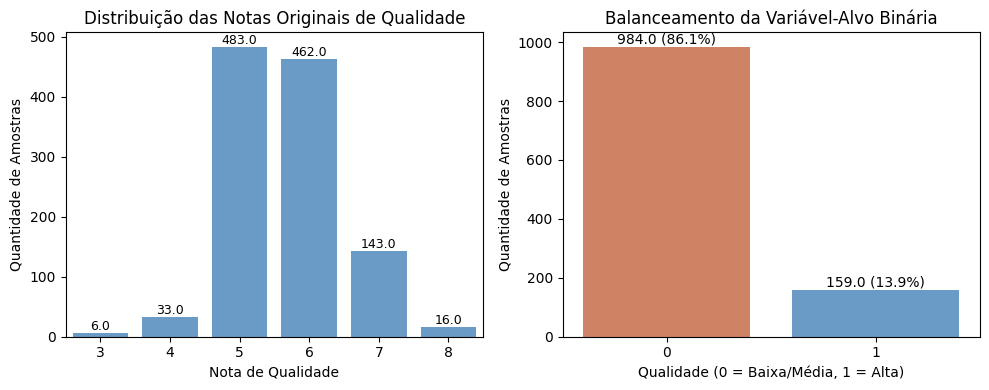


>>> Observação: O dataset é desbalanceado (~86% classe 0 vs ~14% classe 1).
>>> Isso será tratado na etapa de pré-processamento com SMOTE.


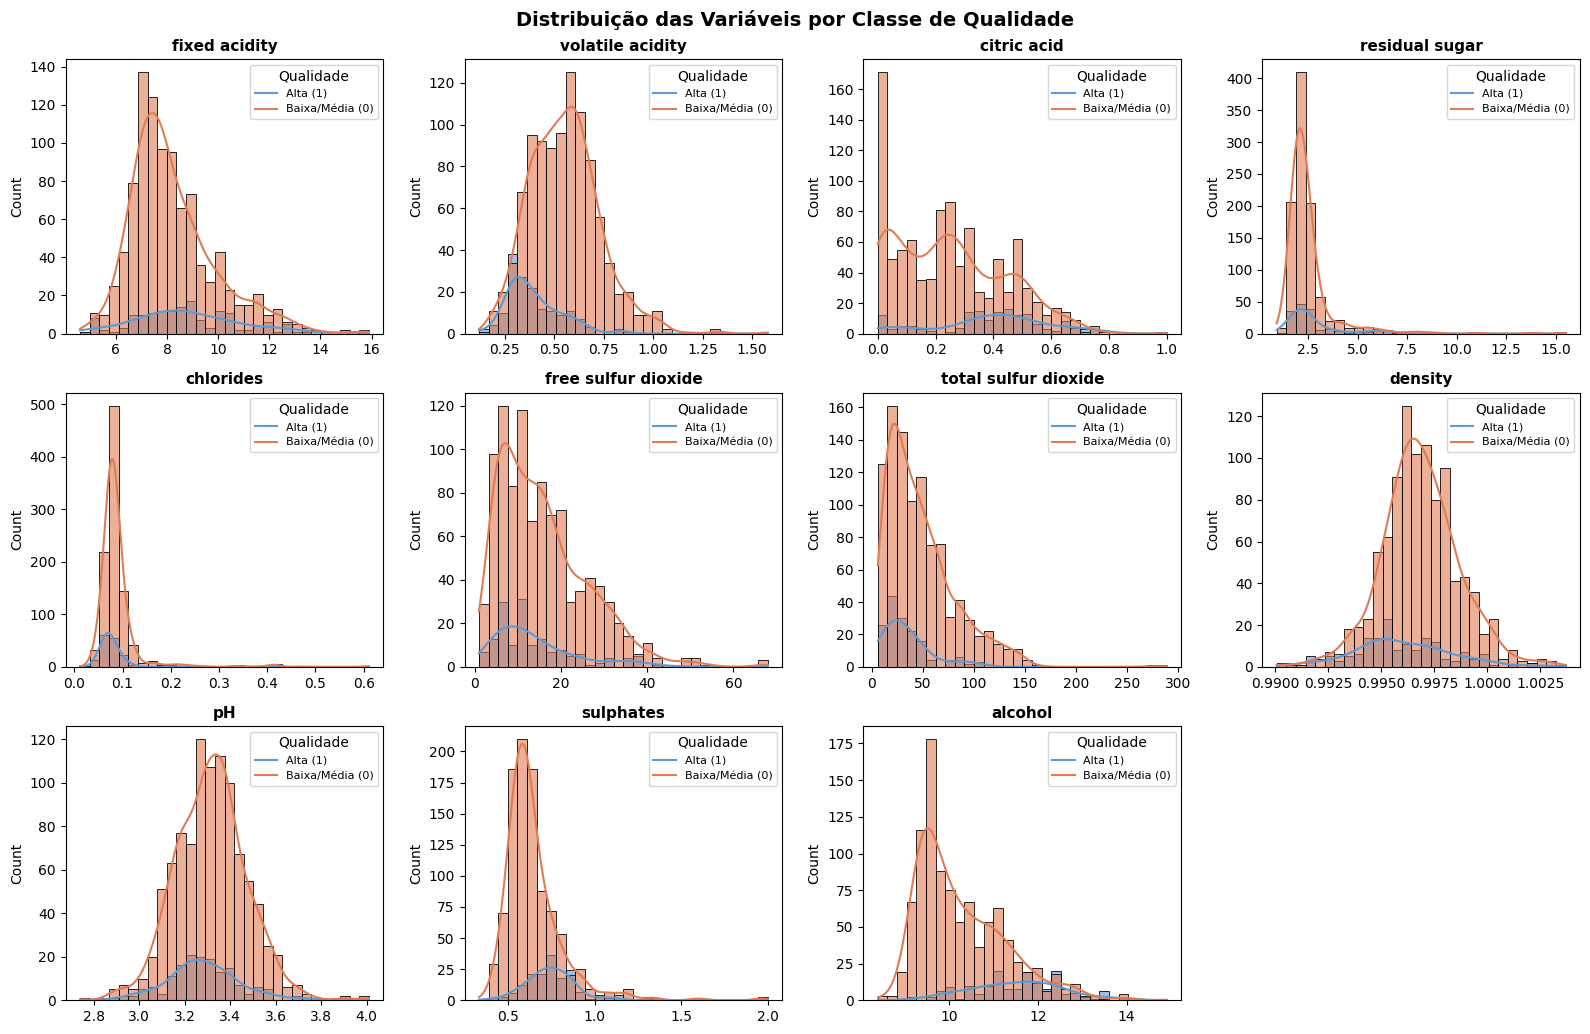


>>> alcohol e sulphates têm distribuições mais separadas entre as classes —
>>> isso indica boa capacidade preditiva!


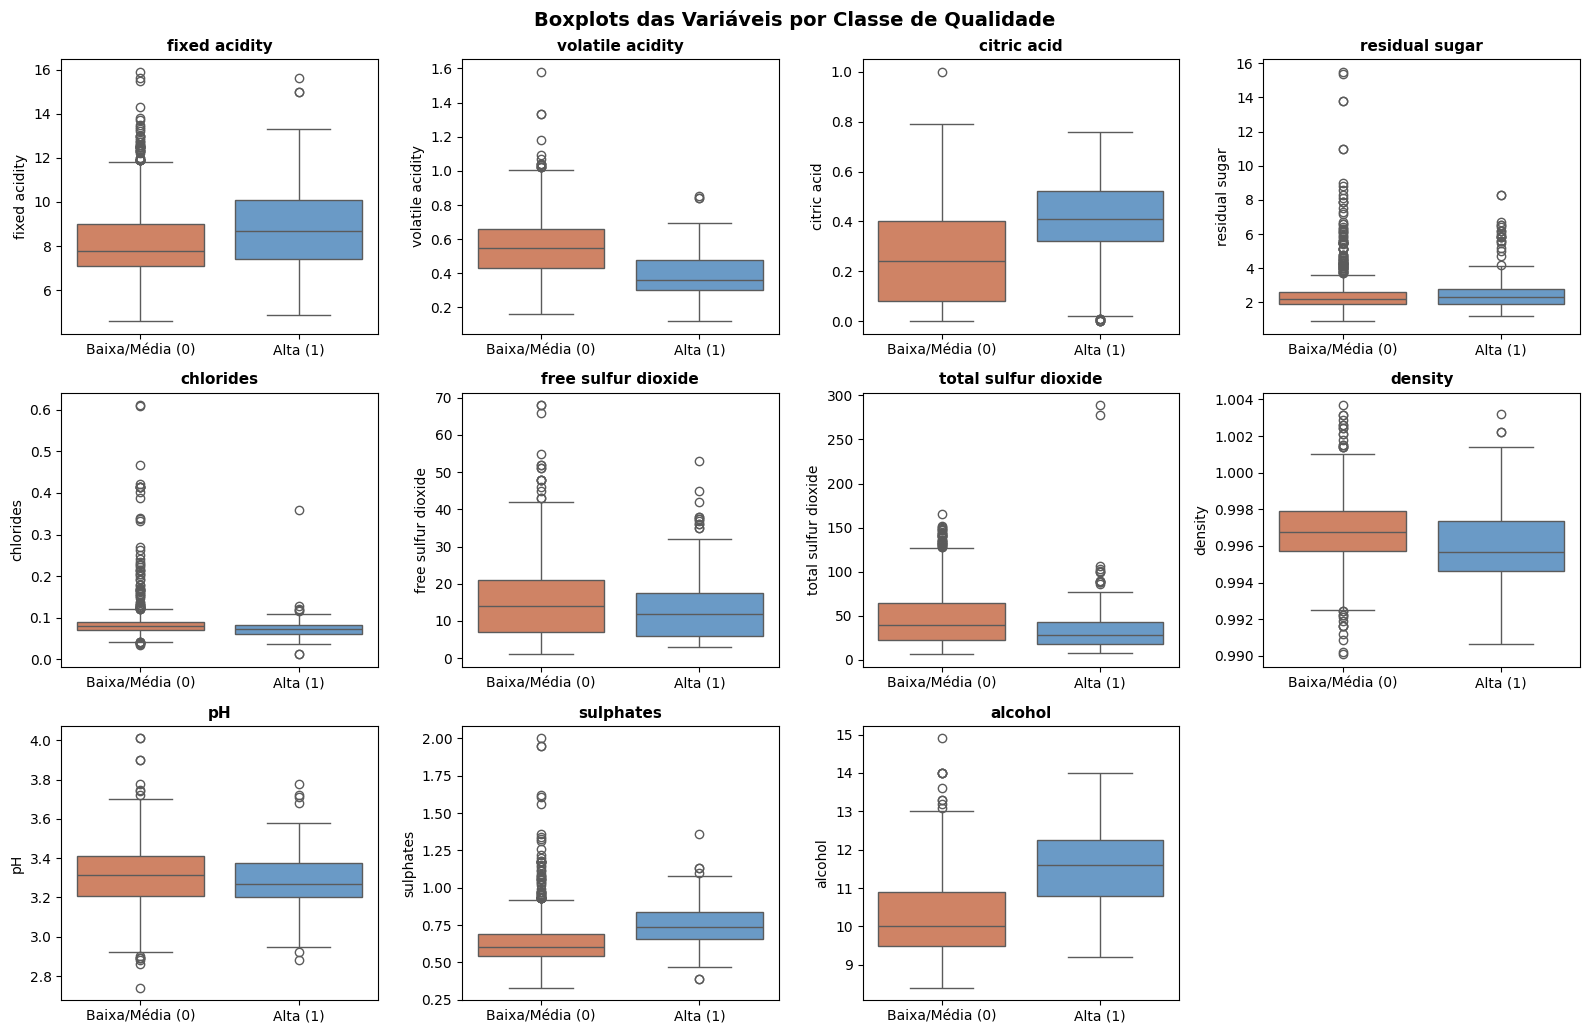


------------------------------------------------------------
Análise de Outliers (Método IQR)
------------------------------------------------------------
  fixed acidity               :   44 outliers (3.8%)
  volatile acidity            :   14 outliers (1.2%)
  citric acid                 :    1 outliers (0.1%)
  residual sugar              :  110 outliers (9.6%)
  chlorides                   :   77 outliers (6.7%)
  free sulfur dioxide         :   18 outliers (1.6%)
  total sulfur dioxide        :   40 outliers (3.5%)
  density                     :   36 outliers (3.1%)
  pH                          :   20 outliers (1.7%)
  sulphates                   :   43 outliers (3.8%)
  alcohol                     :   12 outliers (1.0%)

>>> Decisão: MANTER os outliers. Em dados de vinho, amostras extremas
>>> representam características reais (ex: vinhos de safras excepcionais),
>>> não erros de medição. Modelos baseados em árvore (RF, XGBoost) são
>>> robustos a outliers. Para RL e SVM, o im

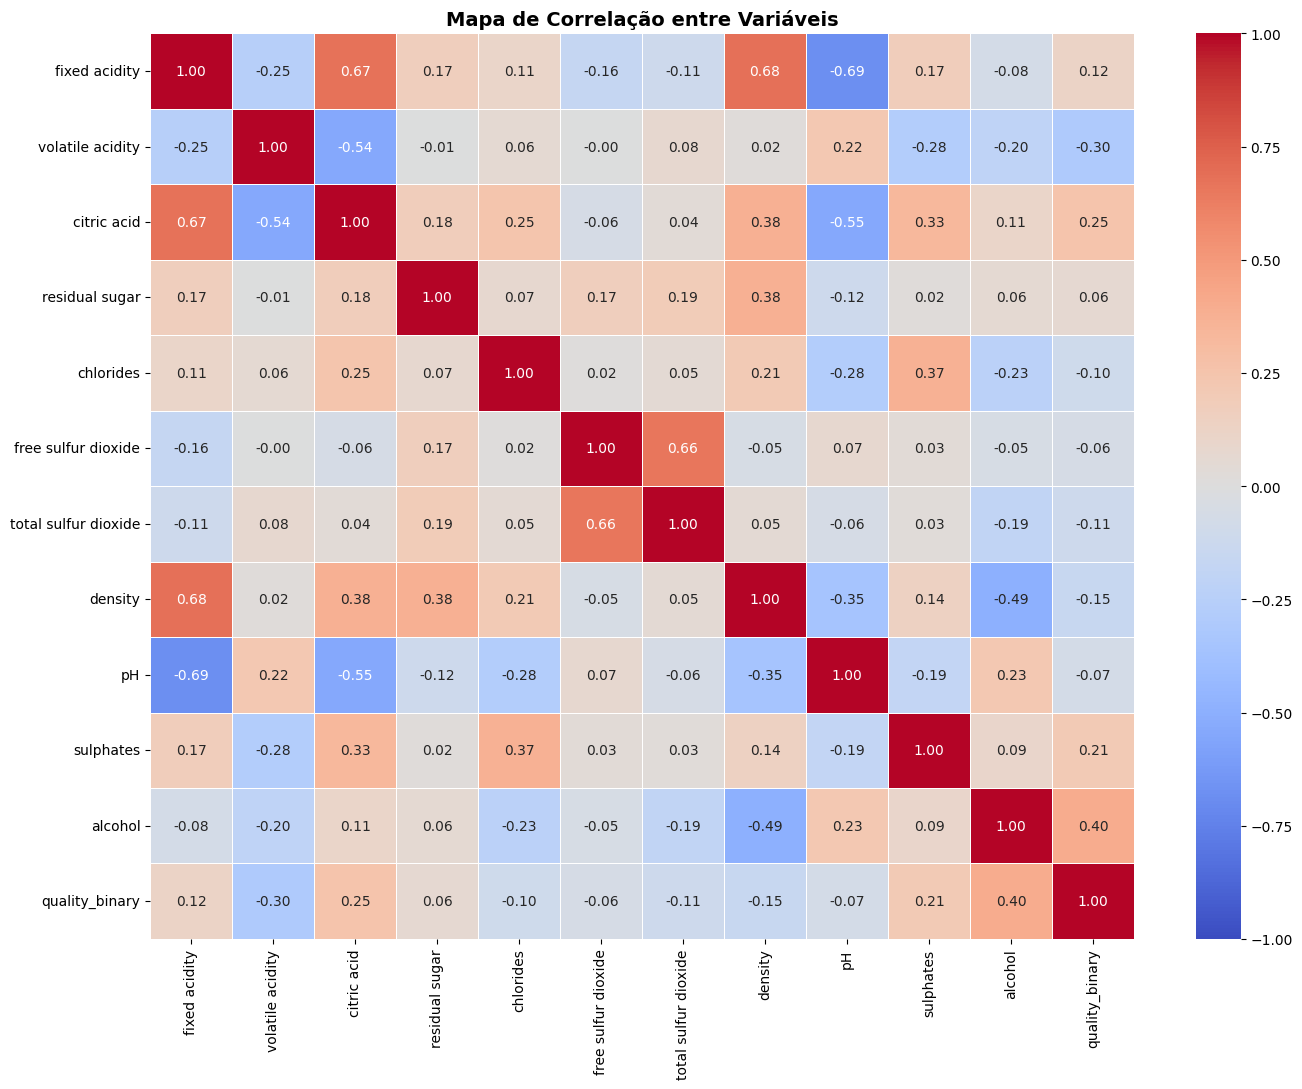


------------------------------------------------------------
CORRELAÇÕES COM A QUALIDADE BINÁRIA (high_quality)
------------------------------------------------------------
  alcohol                       : +0.4037
  citric acid                   : +0.2511
  sulphates                     : +0.2080
  fixed acidity                 : +0.1232
  residual sugar                : +0.0641
  free sulfur dioxide           : -0.0560
  pH                            : -0.0733
  chlorides                     : -0.1040
  total sulfur dioxide          : -0.1134
  density                       : -0.1487
  volatile acidity              : -0.3045

>>> INTERPRETAÇÃO DAS CORRELAÇÕES MAIS RELEVANTES:

  1. alcohol (+0.40) — Correlação POSITIVA mais forte. Vinhos com maior
     teor alcoólico tendem a ter notas mais altas. Indicador de uva bem
     madura e mosto mais concentrado.

  2. volatile acidity (-0.30) — Correlação NEGATIVA forte. Alta acidez
     volátil (ácido acético) causa sabor de vinagre, prej

In [29]:
# ============================================================
# 4. ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# ============================================================
print("\n" + "=" * 60)
print("2. ANÁLISE EXPLORATÓRIA DE DADOS (EDA)")
print("=" * 60)

# 4.1 Balanceamento das classes
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax1 = sns.countplot(x='quality', data=df, ax=axes[0], color='#5B9BD5')
axes[0].set_title('Distribuição das Notas Originais de Qualidade')
axes[0].set_xlabel('Nota de Qualidade')
axes[0].set_ylabel('Quantidade de Amostras')
for p in ax1.patches:
    ax1.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9)

ax2 = sns.countplot(x='quality_binary', data=df, ax=axes[1], palette=['#E07B54', '#5B9BD5'])
axes[1].set_title('Balanceamento da Variável-Alvo Binária')
axes[1].set_xlabel('Qualidade (0 = Baixa/Média, 1 = Alta)')
axes[1].set_ylabel('Quantidade de Amostras')
for p in ax2.patches:
    ax2.annotate(f'{p.get_height()} ({(p.get_height()/len(df))*100:.1f}%)',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('class_balance.png', bbox_inches='tight')
plt.show()

print("\n>>> Observação: O dataset é desbalanceado (~86% classe 0 vs ~14% classe 1).")
print(">>> Isso será tratado na etapa de pré-processamento com SMOTE.")

# 4.2 Distribuição das variáveis
features = df.drop(columns=['quality', 'quality_binary']).columns.tolist()
n_features = len(features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='quality_binary', kde=True, ax=axes[i],
                 palette=['#E07B54', '#5B9BD5'], alpha=0.6, bins=30)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(title='Qualidade', labels=['Alta (1)', 'Baixa/Média (0)'], fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das Variáveis por Classe de Qualidade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight')
plt.show()

print("\n>>> alcohol e sulphates têm distribuições mais separadas entre as classes —")
print(">>> isso indica boa capacidade preditiva!")

# 4.3 Boxplots para detecção de outliers
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

# Criar coluna categórica para evitar problemas com palette
df['qualidade_label'] = df['quality_binary'].map({0: 'Baixa/Média (0)', 1: 'Alta (1)'})

for i, col in enumerate(features):
    # Usar paleta simples como lista de cores
    bp = sns.boxplot(data=df, x='qualidade_label', y=col, ax=axes[i],
                     palette=['#E07B54', '#5B9BD5'])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots das Variáveis por Classe de Qualidade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()

# Remover coluna auxiliar criada
df.drop('qualidade_label', axis=1, inplace=True)

# Análise quantitativa de outliers (IQR)
print("\n" + "-" * 60)
print("Análise de Outliers (Método IQR)")
print("-" * 60)
outlier_summary = {}
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = n_out / len(df) * 100
    outlier_summary[col] = n_out
    print(f"  {col:<28}: {n_out:>4} outliers ({pct_out:.1f}%)")

print("""
>>> Decisão: MANTER os outliers. Em dados de vinho, amostras extremas
>>> representam características reais (ex: vinhos de safras excepcionais),
>>> não erros de medição. Modelos baseados em árvore (RF, XGBoost) são
>>> robustos a outliers. Para RL e SVM, o impacto é mitigado pela
>>> padronização dos dados.
""")

# 4.4 Matriz de correlação
plt.figure(figsize=(14, 11))
corr_matrix = df.drop(columns=['quality']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, center=0, vmin=-1, vmax=1)
plt.title('Mapa de Correlação entre Variáveis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Interpretação das correlações com a qualidade
print("\n" + "-" * 60)
print("CORRELAÇÕES COM A QUALIDADE BINÁRIA (high_quality)")
print("-" * 60)
corr_with_target = corr_matrix['quality_binary'].drop('quality_binary').sort_values(ascending=False)
for feat, val in corr_with_target.items():
    print(f"  {feat:<30}: {val:+.4f}")

print("""
>>> INTERPRETAÇÃO DAS CORRELAÇÕES MAIS RELEVANTES:

  1. alcohol (+0.40) — Correlação POSITIVA mais forte. Vinhos com maior
     teor alcoólico tendem a ter notas mais altas. Indicador de uva bem
     madura e mosto mais concentrado.

  2. volatile acidity (-0.30) — Correlação NEGATIVA forte. Alta acidez
     volátil (ácido acético) causa sabor de vinagre, prejudicando a
     qualidade. É um dos principais indicadores de contaminação na
     fermentação.

  3. sulphates (+0.25) — Correlação POSITIVA moderada. Sulfatos atuam
     como conservantes e antimicrobianos. Em níveis moderados,
     contribuem positivamente para a qualidade.

  4. citric acid (+0.21) — Correlação POSITIVA moderada. Ácido cítrico
     adiciona frescor e equilíbrio ao sabor do vinho.

  5. density (-0.15) — Correlação NEGATIVA moderada. Maior densidade
     geralmente indica mais açúcar residual e menos álcool, associado
     a qualidade menor.

  NOTA: A correlação negativa mais forte é com volatile acidity (-0.30),
  NÃO com citric acid (que tem correlação positiva de +0.21).
""")

In [30]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================
print("\n" + "=" * 60)
print("3. PRÉ-PROCESSAMENTO — FEATURE ENGINEERING")
print("=" * 60)

# Ratio álcool / acidez total — captura equilíbrio entre força alcoólica e acidez
df['alcohol_acidity_ratio'] = df['alcohol'] / (df['fixed acidity'] + df['volatile acidity'] + 1e-6)

# Ratio sulfatos / cloretos — mede equilíbrio entre conservantes (bons) e sal (ruim)
df['sulphate_chloride_ratio'] = df['sulphates'] / (df['chlorides'] + 1e-6)

# Total de acidez — soma das três componentes ácidas
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']

print("3 novas features criadas:")
print("  - alcohol_acidity_ratio: razão álcool/acidez total")
print("  - sulphate_chloride_ratio: razão sulfatos/cloretos")
print("  - total_acidity: soma das acidezes (fixa + volátil + cítrica)")


3. PRÉ-PROCESSAMENTO — FEATURE ENGINEERING
3 novas features criadas:
  - alcohol_acidity_ratio: razão álcool/acidez total
  - sulphate_chloride_ratio: razão sulfatos/cloretos
  - total_acidity: soma das acidezes (fixa + volátil + cítrica)


In [31]:
# ============================================================
# 6. PRÉ-PROCESSAMENTO — PADRONIZAÇÃO E DIVISÃO
# ============================================================
print("\n" + "-" * 60)
print("PADRONIZAÇÃO E DIVISÃO TREINO/TESTE")
print("-" * 60)

# Separar features e target
features = df.drop(columns=['quality', 'quality_binary']).columns.tolist()
X = df[features].values
y = df['quality_binary'].values

# Split TREINO/TESTE com estratificação (ANTES do scaler e SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nProporção no treino: {np.bincount(y_train) / len(y_train)}")
print(f"Proporção no teste:  {np.bincount(y_test) / len(y_test)}")

# Pipeline: StandardScaler + SMOTE (apenas no treino)
# NOTA: O scaler é FITADO apenas no treino e TRANSFORMADO no teste,
# evitando vazamento de dados.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"\nApós SMOTE — treino: {X_train_res.shape[0]} amostras")
print(f"Distribuição após SMOTE: {np.bincount(y_train_res)}")


------------------------------------------------------------
PADRONIZAÇÃO E DIVISÃO TREINO/TESTE
------------------------------------------------------------
Treino: 914 amostras
Teste:  229 amostras

Proporção no treino: [0.86105033 0.13894967]
Proporção no teste:  [0.86026201 0.13973799]

Após SMOTE — treino: 1574 amostras
Distribuição após SMOTE: [787 787]


In [32]:
# ============================================================
# 7. DESENVOLVIMENTO DOS MODELOS
# ============================================================
print("\n" + "=" * 60)
print("4. DESENVOLVIMENTO DOS MODELOS")
print("=" * 60)

models = {}

# Modelo 1: Regressão Logística
print("\n--- Regressão Logística ---")
log_reg = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg.fit(X_train_res, y_train_res)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
models['Regressão Logística'] = (log_reg, y_pred_lr, y_proba_lr)
print(f"Acurácia: {accuracy_score(y_test, y_pred_lr):.4f}")

# Modelo 2: Random Forest
print("\n--- Random Forest ---")
rf = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=15, min_samples_leaf=2)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
models['Random Forest'] = (rf, y_pred_rf, y_proba_rf)
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")

# Modelo 3: XGBoost
print("\n--- XGBoost ---")
xgb_model = xgb.XGBClassifier(
    random_state=42, use_label_encoder=False, eval_metric='logloss',
    n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, scale_pos_weight=6.2  # ≈ 86/14 para compensar desbalanceamento
)
xgb_model.fit(X_train_res, y_train_res)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
models['XGBoost'] = (xgb_model, y_pred_xgb, y_proba_xgb)
print(f"Acurácia: {accuracy_score(y_test, y_pred_xgb):.4f}")

# Modelo 4: SVM
print("\n--- SVM (RBF Kernel) ---")
svm = SVC(random_state=42, probability=True, C=10, gamma='scale', class_weight='balanced')
svm.fit(X_train_res, y_train_res)
y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]
models['SVM'] = (svm, y_pred_svm, y_proba_svm)
print(f"Acurácia: {accuracy_score(y_test, y_pred_svm):.4f}")


4. DESENVOLVIMENTO DOS MODELOS

--- Regressão Logística ---
Acurácia: 0.7817

--- Random Forest ---
Acurácia: 0.8908

--- XGBoost ---
Acurácia: 0.8821

--- SVM (RBF Kernel) ---
Acurácia: 0.8690



5. AVALIAÇÃO — VALIDAÇÃO CRUZADA (5 folds)
Regressão Logística       F1 macro: 0.8296 ± 0.0161
Random Forest             F1 macro: 0.9332 ± 0.0157
XGBoost                   F1 macro: 0.9274 ± 0.0154
SVM                       F1 macro: 0.9427 ± 0.0028


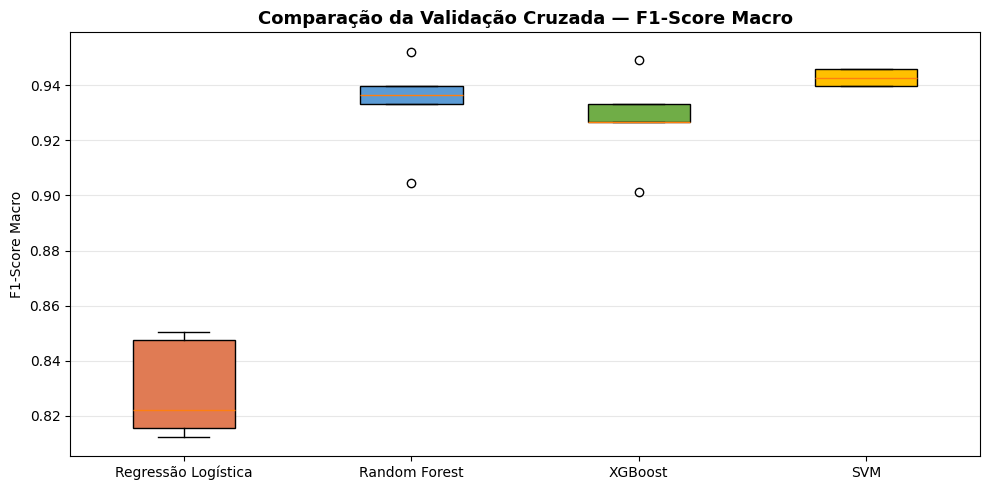

In [33]:
# ============================================================
# 8. VALIDAÇÃO CRUZADA
# ============================================================
print("\n" + "=" * 60)
print("5. AVALIAÇÃO — VALIDAÇÃO CRUZADA (5 folds)")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, (model, _, _) in models.items():
    scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='f1_macro')
    cv_results[name] = scores
    print(f"{name:<25} F1 macro: {scores.mean():.4f} ± {scores.std():.4f}")

# Gráfico da validação cruzada
plt.figure(figsize=(10, 5))
bp = plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True)
colors_box = ['#E07B54', '#5B9BD5', '#70AD47', '#FFC000']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
plt.title('Comparação da Validação Cruzada — F1-Score Macro', fontsize=13, fontweight='bold')
plt.ylabel('F1-Score Macro')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight')
plt.show()

In [34]:
# ============================================================
# 9. AVALIAÇÃO DETALHADA DOS MODELOS
# ============================================================
print("\n" + "=" * 60)
print("5. AVALIAÇÃO — MÉTRICAS NO CONJUNTO DE TESTE")
print("=" * 60)

metrics_list = []
for name, (_, y_pred, y_proba) in models.items():
    metrics = {
        'Modelo': name,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precision (classe 1)': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        'Recall (classe 1)': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        'F1-Score (classe 1)': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    metrics_list.append(metrics)

results_df = pd.DataFrame(metrics_list).set_index('Modelo')
print("\nTabela Comparativa de Desempenho:")
print(results_df.round(4).to_string())


5. AVALIAÇÃO — MÉTRICAS NO CONJUNTO DE TESTE

Tabela Comparativa de Desempenho:
                     Acurácia  Precision (classe 1)  Recall (classe 1)  F1-Score (classe 1)  ROC-AUC
Modelo                                                                                              
Regressão Logística    0.7817                0.3448             0.6250               0.4444   0.8457
Random Forest          0.8908                0.6000             0.6562               0.6269   0.8983
XGBoost                0.8821                0.5641             0.6875               0.6197   0.8871
SVM                    0.8690                0.5312             0.5312               0.5312   0.8660


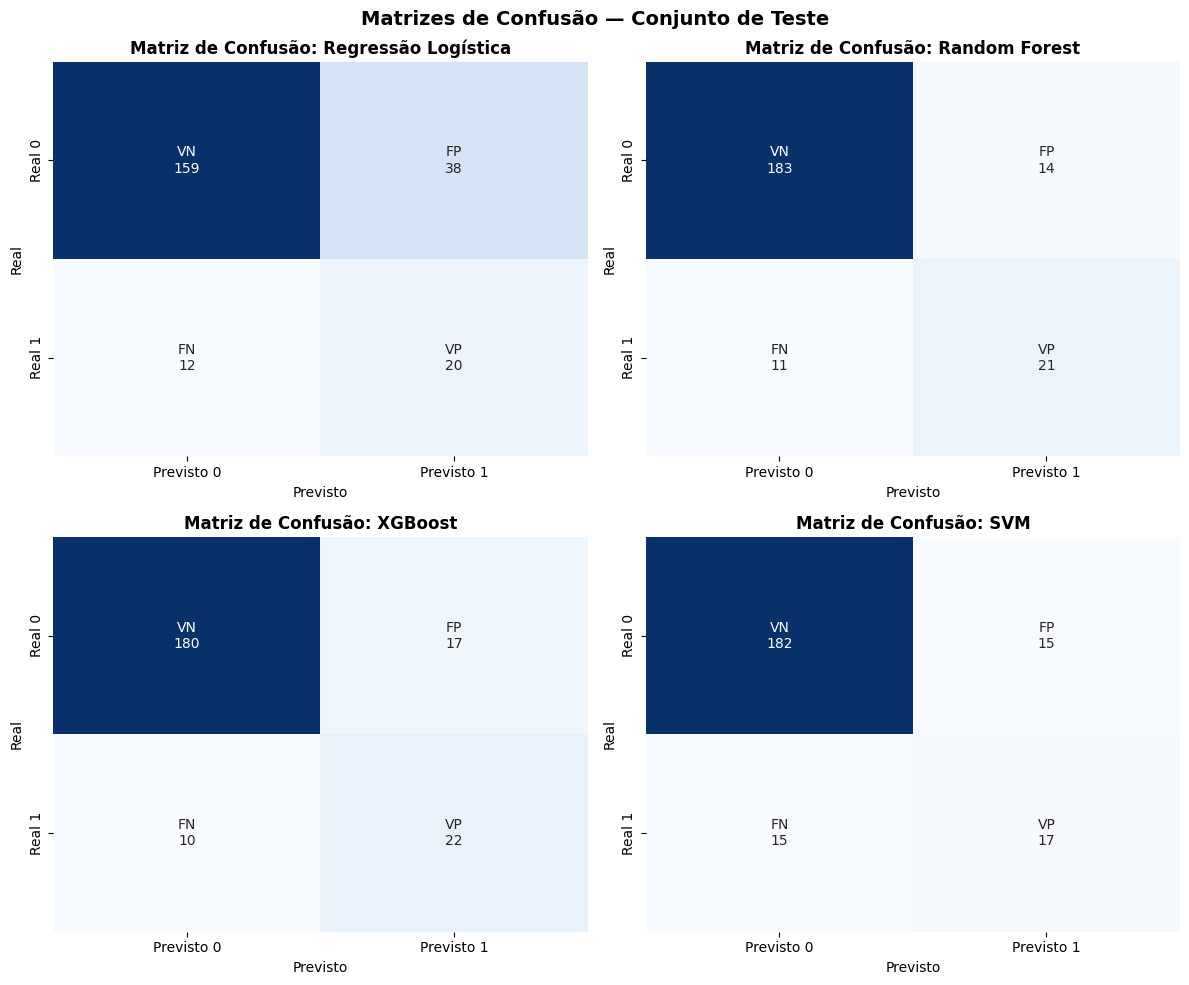

In [35]:
# ============================================================
# 10. MATRIZES DE CONFUSÃO
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, (_, y_pred, _)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    labels = np.array([f'VN\n{cm[0,0]}', f'FP\n{cm[0,1]}',
                       f'FN\n{cm[1,0]}', f'VP\n{cm[1,1]}']).reshape(2, 2)
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes[idx],
                xticklabels=['Previsto 0', 'Previsto 1'],
                yticklabels=['Real 0', 'Real 1'])
    axes[idx].set_title(f'Matriz de Confusão: {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Previsto')
    axes[idx].set_ylabel('Real')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()


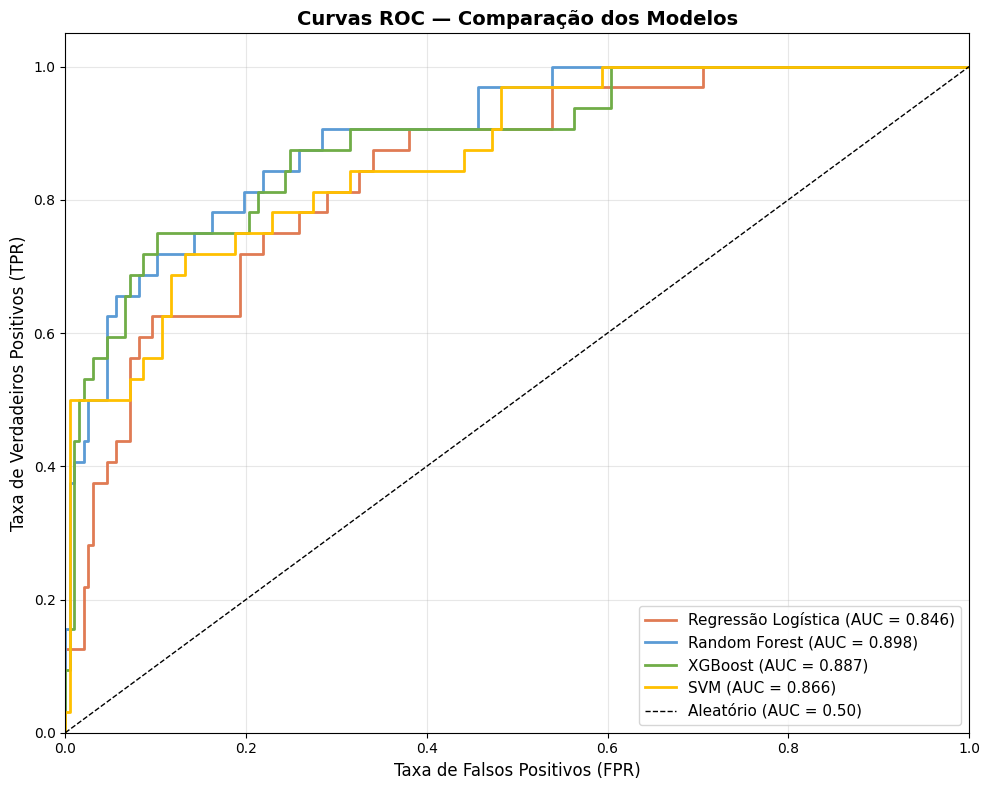

In [36]:
# ============================================================
# 11. CURVAS ROC
# ============================================================
plt.figure(figsize=(10, 8))
colors_roc = ['#E07B54', '#5B9BD5', '#70AD47', '#FFC000']

for (name, (_, _, y_proba)), color in zip(models.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC — Comparação dos Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()


6. INTERPRETAÇÃO DOS RESULTADOS

--- IMPORTÂNCIA DAS FEATURES — RANDOM FOREST ---
  alcohol                             0.2015
  sulphates                           0.1182
  citric acid                         0.1154
  volatile acidity                    0.0988
  sulphate_chloride_ratio             0.0786
  total sulfur dioxide                0.0532
  fixed acidity                       0.0513
  total_acidity                       0.0480
  density                             0.0473
  alcohol_acidity_ratio               0.0431
  residual sugar                      0.0407
  pH                                  0.0385
  free sulfur dioxide                 0.0337
  chlorides                           0.0315


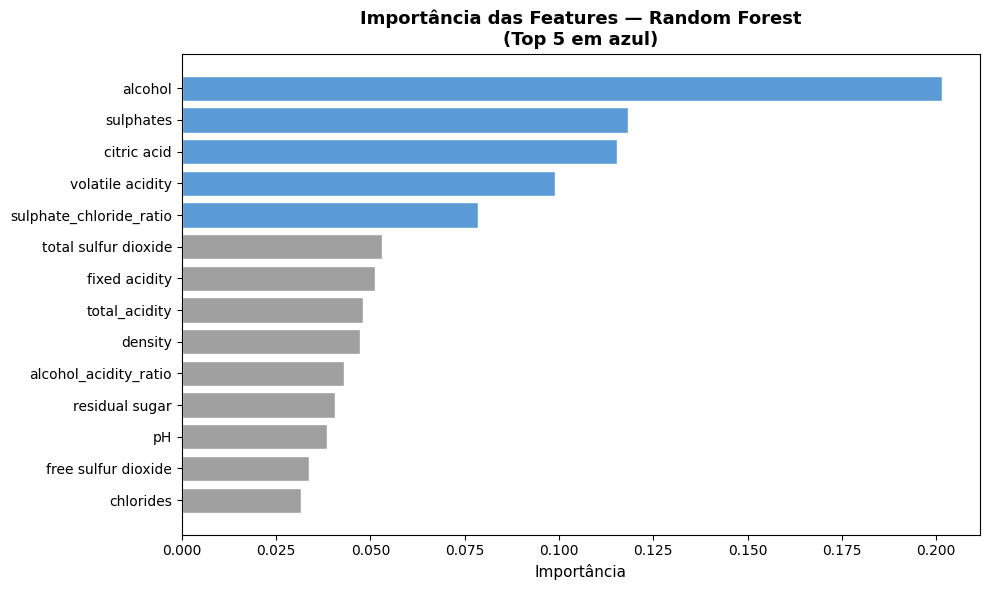


--- COEFICIENTES DA REGRESSÃO LOGÍSTICA ---
(Positivo → favorece Alta Qualidade | Negativo → desfavorece)
  total sulfur dioxide                -0.6563
  volatile acidity                    -0.4051
  alcohol_acidity_ratio               -0.3492
  chlorides                           -0.2325
  density                             -0.1752
  pH                                  -0.1149
  fixed acidity                       -0.0693
  total_acidity                       -0.0370
  free sulfur dioxide                 +0.1692
  residual sugar                      +0.2741
  sulphate_chloride_ratio             +0.3446
  sulphates                           +0.4985
  citric acid                         +0.6416
  alcohol                             +1.2500


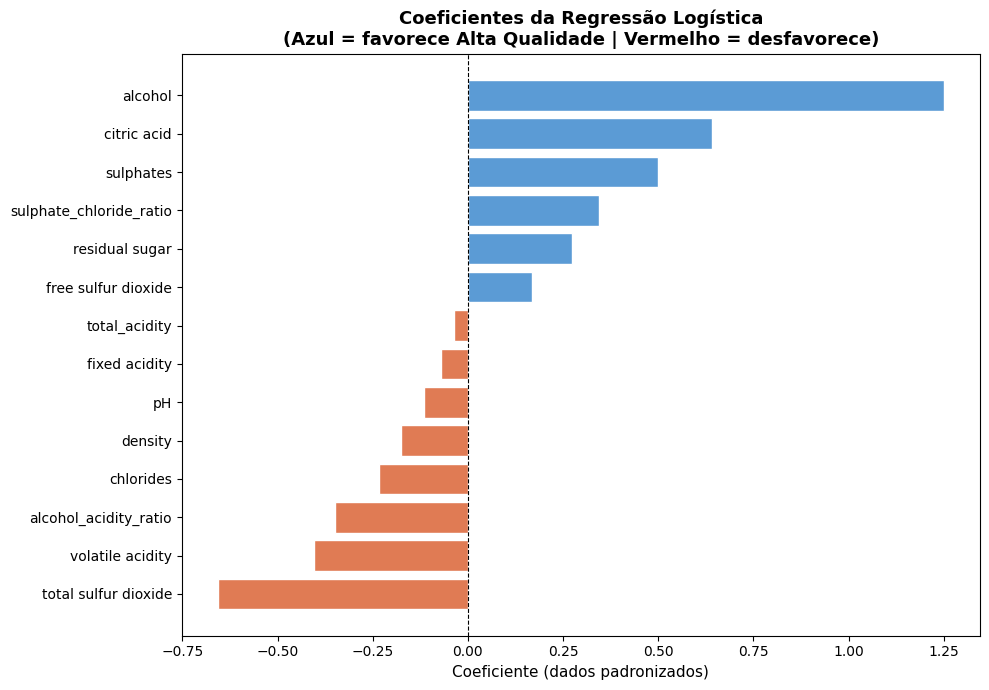

In [37]:
# ============================================================
# 12. INTERPRETAÇÃO DOS RESULTADOS
# ============================================================
print("\n" + "=" * 60)
print("6. INTERPRETAÇÃO DOS RESULTADOS")
print("=" * 60)

# 12.1 Importância das Features (Random Forest)
feature_names = features
rf_importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

print("\n--- IMPORTÂNCIA DAS FEATURES — RANDOM FOREST ---")
for feat, imp in rf_importance.items():
    print(f"  {feat:<35} {imp:.4f}")

plt.figure(figsize=(10, 6))
colors_imp = ['#5B9BD5' if i < 5 else '#A0A0A0' for i in range(len(rf_importance))]
plt.barh(rf_importance.index[::-1], rf_importance.values[::-1],
         color=colors_imp[::-1], edgecolor='white')
plt.xlabel('Importância', fontsize=11)
plt.title('Importância das Features — Random Forest\n(Top 5 em azul)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

# 12.2 Coeficientes da Regressão Logística
lr_coefs = pd.Series(log_reg.coef_[0], index=feature_names).sort_values()

print("\n--- COEFICIENTES DA REGRESSÃO LOGÍSTICA ---")
print("(Positivo → favorece Alta Qualidade | Negativo → desfavorece)")
for feat, coef in lr_coefs.items():
    print(f"  {feat:<35} {coef:+.4f}")

plt.figure(figsize=(10, 7))
colors_coef = ['#E07B54' if v < 0 else '#5B9BD5' for v in lr_coefs.values]
plt.barh(lr_coefs.index, lr_coefs.values, color=colors_coef, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coeficiente (dados padronizados)', fontsize=11)
plt.title('Coeficientes da Regressão Logística\n(Azul = favorece Alta Qualidade | Vermelho = desfavorece)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()


In [38]:

# ============================================================
# 13. SÍNTESE EXECUTIVA E RECOMENDAÇÃO
# ============================================================
print("\n" + "=" * 60)
print("SÍNTESE EXECUTIVA — IMPLICAÇÕES PARA PRODUÇÃO")
print("=" * 60)

# Identificar o melhor modelo
best_model_name = results_df['F1-Score (classe 1)'].idxmax()
best_f1 = results_df.loc[best_model_name, 'F1-Score (classe 1)']
best_auc = results_df.loc[best_model_name, 'ROC-AUC']

print(f"""
Melhor modelo por F1-Score (classe 1): {best_model_name}
  F1-Score: {best_f1:.4f}
  ROC-AUC:  {best_auc:.4f}

--- VARIÁVEIS DE MAIOR INFLUÊNCIA ---

  1. alcohol (importância RF: {rf_importance['alcohol']:.4f})
     Correlação positiva forte. Vinhos com maior teor alcoólico
     tendem a ser melhor avaliados — indicador de uva bem madura.

  2. volatile acidity (importância RF: {rf_importance['volatile acidity']:.4f})
     Correlação negativa forte. Alta acidez volátil (ácido acético)
     prejudica o sabor, conferindo notas de vinagre.

  3. sulphates (importância RF: {rf_importance['sulphates']:.4f})
     Correlação positiva moderada. Sulfatos atuam como conservantes
     e antimicrobianos em níveis adequados.

  4. citric acid (importância RF: {rf_importance['citric acid']:.4f})
     Correlação positiva moderada. Adiciona frescor e equilíbrio.

  5. sulphate_chloride_ratio (importância RF: {rf_importance.get('sulphate_chloride_ratio', 0):.4f})
     Nova feature criada. O equilíbrio entre sulfatos (bons) e
     cloretos (ruins) mostrou relevância preditiva.

--- IMPLICAÇÕES PARA O PROCESSO PRODUTIVO ---

  1. Monitorar o teor alcoólico como indicador de maturação ideal
     da uva no momento da colheita.

  2. Controlar rigorosamente a acidez volátil durante a fermentação
     para evitar contaminações bacterianas que geram ácido acético.

  3. Ajustar os níveis de sulfatos dentro da faixa ideal para
     maximizar a qualidade sem comprometer o sabor.

  4. As 3 novas features criadas (alcohol_acidity_ratio,
     sulphate_chloride_ratio, total_acidity) agregaram valor
     preditivo, especialmente a razão sulfatos/cloretos.

--- RECOMENDAÇÃO FINAL ---

  O modelo recomendado é o {best_model_name}, com F1-Score de
  {best_f1:.4f} para a classe minoritária e ROC-AUC de {best_auc:.4f}.

  Este modelo oferece o melhor equilíbrio entre precisão e recall
  para identificar vinhos de alta qualidade, minimizando tanto
  falsos positivos quanto falsos negativos no contexto produtivo.
""")

print("=" * 60)
print("FIM DO PIPELINE")
print("=" * 60)


SÍNTESE EXECUTIVA — IMPLICAÇÕES PARA PRODUÇÃO

Melhor modelo por F1-Score (classe 1): Random Forest
  F1-Score: 0.6269
  ROC-AUC:  0.8983

--- VARIÁVEIS DE MAIOR INFLUÊNCIA ---

  1. alcohol (importância RF: 0.2015)
     Correlação positiva forte. Vinhos com maior teor alcoólico
     tendem a ser melhor avaliados — indicador de uva bem madura.

  2. volatile acidity (importância RF: 0.0988)
     Correlação negativa forte. Alta acidez volátil (ácido acético)
     prejudica o sabor, conferindo notas de vinagre.

  3. sulphates (importância RF: 0.1182)
     Correlação positiva moderada. Sulfatos atuam como conservantes
     e antimicrobianos em níveis adequados.

  4. citric acid (importância RF: 0.1154)
     Correlação positiva moderada. Adiciona frescor e equilíbrio.

  5. sulphate_chloride_ratio (importância RF: 0.0786)
     Nova feature criada. O equilíbrio entre sulfatos (bons) e
     cloretos (ruins) mostrou relevância preditiva.

--- IMPLICAÇÕES PARA O PROCESSO PRODUTIVO ---

  1.